# Notebook 4: Intro to Weights & Biases with an MLP
*Author: Sara Speelman; 2026-03-06*

In this notebook, we use the same end-to-end ML workflow as in previous sessions and now we log our results with **Weights & Biases (W&B)**.

We train a feed-forward neural network using an MLP model by scikit-learn, and we compare:
- a baseline logistic regression model,
- a first MLP model,
- an MLP model with tuned hyperparameters via **W&B sweep**

**Learning outcomes** (new items in bold)
- apply a complete ML workflow for a classification problem
- train and evaluate an **ANN with scikit-learn**
- **track experiments with W&B** (`init`, `config`, `log`, `finish`)
- compare hyperparameter settings with a **W&B sweep**
- model selection
- evaluate a final model on an unseen test set

In [ ]:
import os
import random
import importlib.util
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

random_state = 138
np.random.seed(random_state)
random.seed(random_state)

## 1. Intro to Weights and Biases


**Why** use a tool like W&B? After a while on an ML project, you might end up with lots of experiments scattered across folders, and it becomes hard to connect the hyperparameters you used to the learning curves and results you got. W&B keeps everything in one place by automatically logging configs and metrics, so you can compare runs and stay organized. Of course W&B is only one tool you could use. You might prefer __[MLflow](https://mlflow.org/)__ or another tool.

We will be using the **online W&B dashboard**. Example of a workspace: https://wandb.ai/wandb/wandb_example?nw=nwuser_scott

Steps for our own dashboard:

1. Create a W&B account at https://wandb.ai/site
2. Generate an API key (You might have to choose W&B models on the site first). Store your key safely, but where you can still easily access it.
2. Log in with either:
   - terminal command: `wandb login`
   - or notebook call: `wandb.login()`


Note: This section was inspired by a __[tutorial by W&B](https://colab.research.google.com/github/wandb/examples/blob/master/colabs/intro/Intro_to_Weights_%26_Biases.ipynb#scrollTo=_XXrvlQKnvDW)__


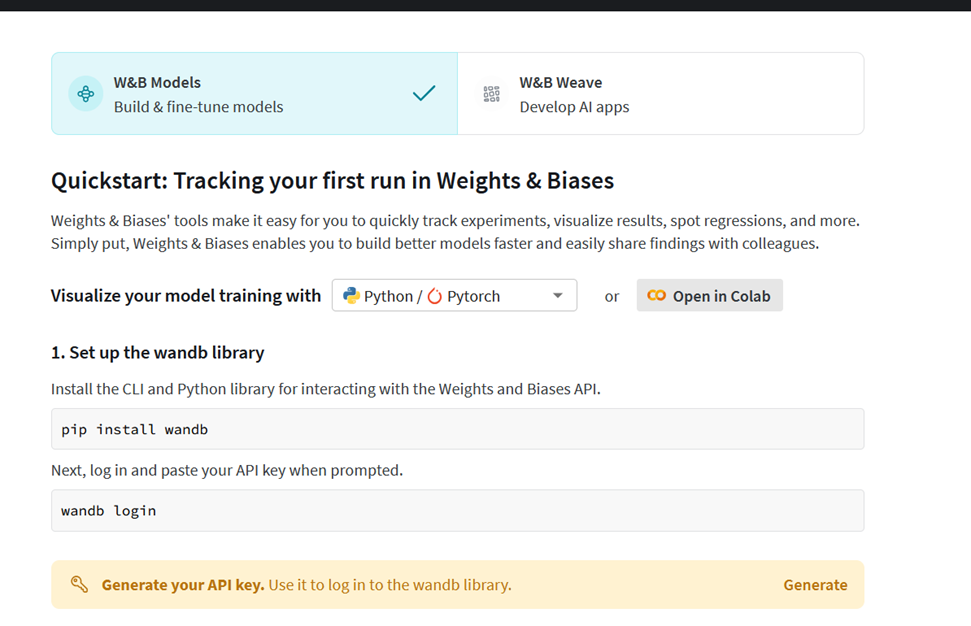

Wandb generates a ton of cell output (logs etc). If you get tired of them: run the following command (before importing wandb); then run the notebook. If you already imported wandb; restart your kernel first, then run the following command and rerun the notebook.

In [ ]:
# DEMO
import os
os.environ["WANDB_SILENT"] = "true"

Let's try and log in:

In [ ]:
# DEMO
import wandb
wandb.login()


We will be working with **W&B Models**, which is meant for training ML models from scratch. You can use it for
- Experiment tracking 
- Visualizations
- Hyperparameter optimization with sweeps

We invite you to have a look at the other tools (W&B Weave, W&B Inference, W&B Training) yourself __[here](https://docs.wandb.ai/get-started)__.

Some key terminology:
- **W&B runs**: 'a single unit of computation logged by W&B', __[overview of runs in the docs](https://docs.wandb.ai/models/runs)__

Some key commands:
- **wandb.init**: Initialize a W&B run object and pass in the hyperparameters you want to track (dictionary for the `config` parameter)
- **wandb.Run.log**: Within your training loop, log metrics such as the accuracy and loss. You can also log visualizations, charts...
- **wandb.finish**: Tell wandbd that the run is finished. Required in notebooks, not in .py files nor if you use **with wandb.init() as run:...**



Read the docs: https://docs.wandb.ai/  
More on logging: https://docs.wandb.ai/models/track/log 

In [ ]:
# DEMO
# A tiny example (source: https://docs.wandb.ai/models/quickstart)
import wandb
import random

# Log in to Weights & Biases (wandb)
wandb.login()

# Project that the run is recorded to
project = "my-awesome-project"

# Dictionary with hyperparameters
toy_config = {
    'epochs' : 10,
    'lr' : 0.01
}

# Your run, with wandb.init
with wandb.init(project=project, config=toy_config) as run:
    print("W&B run:", run.get_url())
    print("W&B project:", run.get_project_url())
    print("W&B run config:", run.config)
    
    offset = random.random() / 5
    print(f"lr: {run.config['lr']}")

    # Simulate a training run
    for epoch in range(2, run.config['epochs']):
        acc = 1 - 2**-run.config['epochs'] - random.random() / run.config['epochs'] - offset
        loss = 2**-run.config['epochs'] + random.random() / run.config['epochs'] + offset
        print(f"epoch={run.config['epochs']}, accuracy={acc}, loss={loss}")
        run.log({"accuracy": acc, "loss": loss})

## 2. Data Preprocessing

### 2.1 Load the dataset + global inspection
We use the digits dataset from scikit-learn, via __[load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)__ :
- target: digits (digits 0-9)
- features: 64 numerical features per sample (8x8 image flattened)

Is this a regression or a classification problem?

As in previous notebooks, we start with global inspection before training.



In [ ]:
# EXERCISE
# load the digits dataset
digits = load_digits(as_frame=True)

# Extract features and target variable
X = digits.data
y = digits.target

# Print the shapes of the features and target variable, and the unique class labels
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class labels:", np.unique(y))

# Display the first few rows of the features
X.head()

### 2.1 Data Cleaning

Do we need to check duplicate columns as usual with this dataset type?

In [ ]:
# EXERCISE
# Data types checck
print("\nDtypes summary:")
print(X.dtypes.value_counts())

# Check for missing values
print("\nAny missing values in X?", X.isna().any().any())
print("Any missing values in y?", y.isna().any())

# Check for duplicate rows in the features
dup_rows = X.duplicated().sum()
print("Duplicate rows in X:", dup_rows)

# Check the class distribution in the target variable
print("\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(2).to_string())

## 3. Train/validation/test split

- test for final evaluation
- train+val for model development with cross-validation, or:
- train for model training
- val for hyperparameter tuning


Because this is classification, we use **stratification** to preserve class proportions.

In [ ]:
# EXERCISE
# Split the data in training, validation and test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=random_state
)

# Print the shapes of the splits
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# Visualize the class distribution in the splits
# HINT: You could use seaborn's countplot 
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Train Set")

sns.countplot(x=y_val, ax=axes[1])
axes[1].set_title("Validation Set")

sns.countplot(x=y_test, ax=axes[2])
axes[2].set_title("Test Set")

plt.tight_layout()
plt.show()

## 4. EDA

It's very important to visualize the data in order to know what problem we are working with. Let's plot a few training samples.

In [ ]:
# EXERCISE
# Visual inspection: plot a few train digit images
sample_indices = X_train.index[:10]

# Plot settings
n_rows, n_cols = 2, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4))

# Flatten axes so we can iterate in a single loop
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    # Reconstruct 8x8 image from the flattened 64-pixel row
    image = X_train.loc[idx].to_numpy().reshape(8, 8)
    label = y_train.loc[idx]

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

fig.suptitle("Sample digit images (Train set)")
plt.tight_layout()
plt.show()

Would summary statistics be an added value in this problem?  
Would you use feature selection for this problem? Which method would you use then?

## 5. Baseline model

Before training an ANN, we first compare against a simple baseline. We will use **LogisticRegression** as a reference performance floor.

First, let's define the metrics we are interest in. We want to log:

- __[accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)__: fraction of correct predictions
- __[precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)__: tp / (tp + fp) 
- __[recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)__: tp / (tp + fn)
- __[F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)__: (2* tp)/ (2 * tp + fp + fn)

where tp is the number of true positives, fp the number of false positives and fn the number of false negatives   
Read the docs and decide how you want to `average` the scores, since we are working with multiclass classification.

In [ ]:
# EXERCISE
# Define the metrics to log
# name the function 'cumpute_metrics'
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }

In [ ]:
# DEMO
# Function to log metrics to wandb with a prefix and optional step
def log_split_metrics(run, prefix, y_true, y_pred, step=None):
    metrics = compute_metrics(y_true, y_pred)
    metrics = {f"{prefix}/{k}": v for k, v in metrics.items()}
    run.log(metrics, step=step)

We will track this run with W&B. We will log with the usual wandb logging setup:

- __[init](https://docs.wandb.ai/models/ref/python/functions/init)__: Initialize a W&B run object and pass in the `project` name and the hyperparameters you want to track (dictionary for the `config` parameter)
- __[wandb.Run.log()](https://docs.wandb.ai/models/track/log)__: Within your training loop, log metrics such as the accuracy and loss. You can also log visualizations, charts...

For this logistic regression, scikit-learn does not update us on the the loss curve per iteration; we can only log the final result; both on our training and validation set.

In [ ]:
# DEMO
# Run a simple baseline model (Logistic Regression) with a Pipeline and log metrics to wandb
from sklearn.linear_model import LogisticRegression

# Config
logreg_config = {"max_iter": 2000, "random_state": random_state}

wandb.finish()  # Finish any previous runs to avoid conflicts

# Init a wandb run with the logreg_config
with wandb.init(project="baseline_model", config={**logreg_config}) as run:
    # Print the links to the W&B run and project and config
    print("W&B run:", run.get_url())
    print("W&B project:", run.get_project_url())
    print("W&B run config:", run.config)
    
    # Create a pipeline with a StandardScaler and LogisticRegression
    # HINT: use **run.config to unpack the config dict
    baseline = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(**run.config)),
    ])
    # Fit the pipeline on the training set
    baseline.fit(X_train, y_train)

    # Compute metrics with the compute_metrics function for train and val set
    train_metrics = compute_metrics(y_train, baseline.predict(X_train))
    val_metrics   = compute_metrics(y_val, baseline.predict(X_val))

    # Log metrics to wandb; seperate train and val with a prefix
    run.log({f"train/{k}": v for k, v in train_metrics.items()})
    run.log({f"val/{k}": v for k, v in val_metrics.items()})

    # Print validation metrics
    print("Baseline validation metrics (Logistic Regression):")
    for k, v in val_metrics.items():
        print(f"{k}: {v:.4f}")

## 6. Simple Multilayer Perceptron (MLP)

Let's move on to our actual model for today: We build an ANN with scikit-learn's `MLPClassifier` inside a Pipeline:
- scaling with `StandardScaler`
- ANN classifier with 2 hidden layers
    - **early stopping**
    - 15% of our training data as **internal validation set for early stopping**

Have a look at the  __[documentation of MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__ to see how early stopping works here.

We also track this training with a W&B run:
- The metrics that we can obtain **per iteration** from the MLP object can be plotted per step
- For the other metrics, we can only **log the final result**

We can plot the training loss per step; and since we are using early stopping, we can plot the validation loss per step (on an extra internal validation set, not our defined `y_val`)


Start with creating a config dict for out run. Choose logical `hidden_layer_sizes` for the ANN and don't forget about the `early_stopping` with `validation_fraction`. Pass `random_state` as well, for reproducability.

In [ ]:
# EXERCISE
# create a configuration dictionary for the first ANN model
first_ann_config = {
    "hidden_layer_sizes": (16, 16),
    "max_iter": 200,
    "early_stopping": True,
    "random_state": random_state,
    "validation_fraction": 0.15,  
}

In [ ]:
# EXERCISE
# Choose a name for your W&B project
project_name = "simple-ann"  

In [ ]:
# EXERCISE
# Initialize a run, with your config dict
with wandb.init(
    project=project_name,
    config={**first_ann_config},
) as run:
    # Print the links to the W&B run and project, and the config
    print("W&B run:", run.get_url())
    print("W&B project:", run.get_project_url())
    print("W&B run config:", run.config)

    # Create a pipeline with a StandardScaler and an MLPClassifier
    # HINT: use **run.config to unpack the config dict into the MLPClassifier
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ann", MLPClassifier(**run.config)),
    ])

    # Fit the pipeline on the training set
    pipe.fit(X_train, y_train)

    # Get the trained MLPClassifier from the pipeline
    # HINT: use pipe.named_steps
    mlp = pipe.named_steps["ann"]

    # Get the training loss curve and validation scores per step,
    # From the MLPClassifier attributes
    losses = mlp.loss_curve_
    vals = mlp.validation_scores_ if hasattr(mlp, "validation_scores_") else None

    # Log the training loss and validation scores to wandb per step
    # HINT: use run.log() in a loop over the steps/iterations of the training
    # log "train/loss" and "val/accuracy_internal" as keys of the logged dictionary
    for step, loss in enumerate(losses):
        row = {"train/loss": float(loss)}
        if vals is not None and step < len(vals):
            row["val/accuracy_internal"] = float(vals[step])
        run.log(row, step=step)

    # Log the final training + validation metrics to wandb
    # using the log_split_metrics function we defined in a DEMO cell before
    log_split_metrics(run, "train", y_train, pipe.predict(X_train))
    y_val_pred = pipe.predict(X_val)
    log_split_metrics(run, "val", y_val, y_val_pred)


Click the link above to check your project and your first run.

## 7. Hyperparameter tuning with W&B sweep

**Note**: This section is largely based on a __[tutorial by W&B](https://colab.research.google.com/github/wandb/examples/blob/master/colabs/pytorch/Organizing_Hyperparameter_Sweeps_in_PyTorch_with_W%26B.ipynb#scrollTo=KHFxlXhn7LiF)__.  

Running a hyperparameter sweep with W&B requires the following steps:
- **Define the sweep**: create a `config` dict --> specify:
    - hyperparameters to search through
    - search strategy
- **Initialize the sweep** + pass the dict of sweep configurations:  
    - sweep_id = wandb.sweep(sweep_config, project=project)
- **Run the sweep agent**: call `wandb.agent()`, and pass:  
    - `sweep_id` 
    - `function`: the function that defines and trains your model 
    - `count`: the amount of runs to try with different hyperparameters
    - `project`: your project name   

### 7.1 Define your sweep config

In a sweep, there are 3 hyperparameter search methods to choose from  
- **Random search** (`random`): randomly select hyperparameter combinations according to provided distributions
- **Grid search** (`grid`): iterate over every combination of hyperparamenter values
- **Bayesian search** (`bayes`): probabilistic model of metric score as function of hyperparams, choose params with high probability of improving the metric.

You should know random search and grid search from our previous notebooks. You're invited to look into Bayesian search yourselves. We will work with random search here.

More info on sweep configuration options  __[here](https://docs.wandb.ai/models/sweeps/sweep-config-keys)__ .

In [ ]:
# DEMO
sweep_config = {
    "method": "random", }

Next up: Choose your hyperparameter grid or distribution. Have a look an the `MLPClassifier` __[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__ and make sure you understand which hyperparameters you are tuning and why. Try and choose logical hyperparameter values. 

Your 'parameters' dict should be a **nested dict**. Provide the 
- name of the **parameters** you want to optimize
    - and one or more **search constraints** for each hyperparameter. These search constraint are related to the distributions of the hyperparameters ; e.g.
        - value
        - values
        - distribution
        - probabilites
        - min, max

W&B sets the following distributions based on the following conditions (if a distribution is not specified):

- **categorical** if you specify values
- **int_uniform** if you specify max and min as integers
- **uniform** if you specify max and min as floats
- **constant** if you provide a set to value


If you're unsure how to get started, have a look at the __[parameters documentation](https://docs.wandb.ai/models/sweeps/sweep-config-keys#parameters)__.

In [ ]:
import math
# EXERCISE
# Parameters to sweep over
parameters = {
        "hidden_layer_sizes": {"values": [(8,), (32,), (64,), (8, 8), (64, 32)]},
        "learning_rate_init": {
            "distribution": "log_uniform_values",
            "min": 1e-4,
            "max": 1e-2,
        },
        "batch_size": {"values": [16, 32, 64, 128]},
        "activation": {"values": ["relu", "tanh"]},
        "alpha": {"values": [1e-4, 1e-3]}
    }

# Parameters we don't vary, but want to log with each run
parameters.update({"early_stopping": {"value": True},
        "validation_fraction": {"value": 0.15},
        "random_state": {"value": random_state},
        "max_iter":{"value": 200}})  

# Add the parameters to the sweep config
sweep_config['parameters'] = parameters

In [ ]:
# EXERCISE
# Print the sweep config
import pprint
pprint.pprint(sweep_config)

### 7.2 Initialize the sweep
Use the `wandb.sweep` method to activate a 'sweep controller' (lives on W&B machine). A sweep controller creates the different runs we will do with different hyperparameter sets. The instructions to execute these runs are then picked up by 'agents' who actually perform the run on your machine(s).  

Don't forget to pass your sweep config dict and project name.

In [ ]:
# EXERCISE
# Initialize a sweep
sweep_id = wandb.sweep(sweep_config, project="mlp_sweep")

### 7.3 The code for your ML model
Within our training code, we will use the standard W&B methods:
- __[wandb.init()](https://docs.wandb.ai/models/ref/python/functions/init)__ – Initialize a new W&B run. Each run is a single execution of the training function.
- wandb.Run.config – Pass sweep configuration with the hyperparameters you want to experiment with.
- wandb.log() – Logging training loss and final performance metrics

In [ ]:
# EXERCISE
def sweep_train(project="mlp_sweep", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    # Inittialize new wandb run
    with wandb.init(
        project=project,
    ) as run:
        # Extract the config for this run
        cfg = dict(run.config) # the sampled config for this run, set by the Sweep controller

        # Create a pipeline with a StandardScaler and an MLPClassifier
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ann", MLPClassifier(**cfg)),
        ])

        # Fit the pipeline on the training set
        pipe.fit(X_train, y_train)

        # Get the trained MLPClassifier from the pipeline
        mlp = pipe.named_steps["ann"]

        # Get the training loss curve and validation scores per step,
        losses = mlp.loss_curve_
        vals = mlp.validation_scores_ if hasattr(mlp, "validation_scores_") else None

        # Log the training loss and validation scores to wandb per step
        for step, loss in enumerate(losses):
            row = {"train/loss": float(loss)}
            if vals is not None and step < len(vals):
                row["val/accuracy_internal"] = float(vals[step])
            run.log(row, step=step)

        # Log the final training + validation metrics to wandb
        log_split_metrics(run, "train", y_train, pipe.predict(X_train))
        y_val_pred = pipe.predict(X_val)
        log_split_metrics(run, "val", y_val, y_val_pred)

### 7.4 Activate the sweep agents
Sweep agents are responsible for running an experiment with a set of hyperparameter values that you defined in your sweep configuration. You create them with `wandb.agent`. Don't forget to pass:

- the `sweep_id`
- `function`: your training function
- `count`: number of sweep config trials to try; without this our random search would keep running forever
- `project`

Read the docs:__[ wandb agent](https://docs.wandb.ai/models/ref/python/functions/agent)__  

In [ ]:
# EXERCISE
# Run the sweep with the sweep_train function, for 5 runs
wandb.agent(sweep_id, function=sweep_train, count=5, project="mlp_sweep")

Now click the sweep URL that was the output of the cell in which you initialized the sweep with `sweep_id`, and have a look at the results. On your own, do this again with a high count, to help you get an idea of which hyperparameter combinations were performing well.

### Put it all together - Solution Notebook only
A compact overview of the previous cells

In [ ]:
# SOLUTION ONLY
import wandb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# 1. Define the sweep configuration (same as the final sweep_config we had before)
sweep_config = {
    "method": "random", 
    "parameters": {
        "hidden_layer_sizes": {"values": [(8,), (32,), (64,), (8, 8), (64, 32)]},
        "learning_rate_init": {
            "distribution": "log_uniform_values",
            "min": 1e-4,
            "max": 1e-2,
        },
        "batch_size": {"values": [16, 32, 64, 128]},
        "activation": {"values": ["relu", "tanh"]},
        "alpha": {"values": [1e-4, 1e-3]},
        "early_stopping": {"value": True},
        "validation_fraction": {"value": 0.15},
        "random_state": {"value": random_state},
        "max_iter":{"value": 200}
    }
}

# 2. Initialize the sweep
sweep_id = wandb.sweep(sweep_config, project="mlp_sweep")

# 3. Define the training function that the sweep will call
def sweep_train(project="mlp_sweep", X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    # Inittialize new wandb run
    with wandb.init(
        project=project,
    ) as run:
        # Extract the config for this run
        cfg = dict(run.config) # the sampled config for this run, set by the Sweep controller

        # Create a pipeline with a StandardScaler and an MLPClassifier
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ann", MLPClassifier(**cfg)),
        ])

        # Fit the pipeline on the training set
        pipe.fit(X_train, y_train)

        # Get the trained MLPClassifier from the pipeline
        mlp = pipe.named_steps["ann"]

        # Get the training loss curve and validation scores per step,
        losses = mlp.loss_curve_
        vals = mlp.validation_scores_ if hasattr(mlp, "validation_scores_") else None

        # Log the training loss and validation scores to wandb per step
        for step in range(1, len(losses) + 1):
            row = {"train/loss": float(losses[step - 1])}
            if vals is not None and step <= len(vals):
                row["val/accuracy_internal"] = float(vals[step - 1])
            run.log(row, step=step)

        # Log the final training + validation metrics to wandb
        log_split_metrics(run, "train", y_train, pipe.predict(X_train))
        y_val_pred = pipe.predict(X_val)
        log_split_metrics(run, "val", y_val, y_val_pred)
        
# 4. Activate the sweeps agents - run the sweep
wandb.agent(sweep_id, function=sweep_train, count=5, project="mlp_sweep")

## 8. Final model selection and test evaluation

We still need and estimate of how our model will generalize to unseen data. With the optimal hyperparameters, we retrain on `X_trainval`, and evaluate once on the held-out test set.

We use the W&B API to return our `sweep` object. The method `sweep.best_run()` returns the best run sorted by the metric defined in config or the order passed in. We will pass `order`="val/accuracy" here. Is that a good choice for this dataset?

Step by step guide of the whole workflow:

- Run sweep on train (select by val metric); we already did this.
- Use `wandb.Api` to get our sweep
- `sweep.best_run()` with order="the metric of interest"
- Refit pipeline on train+val.
- Evaluate once on test set.

Ideally you would log these results to W&B as well.

In [ ]:
# DEMO
import wandb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

def retrain_best_and_test(
    entity, project, sweep_id,
    X_trainval, y_trainval, X_test, y_test,
):
    api = wandb.Api()

    sweep = api.sweep(f"{entity}/{project}/{sweep_id}")
    best = sweep.best_run(order="val/accuracy")    
    cfg = dict(best.config)

    pipe = Pipeline([("scaler", StandardScaler()),
                     ("ann", MLPClassifier(**cfg))])
    pipe.fit(X_trainval, y_trainval)

    y_pred = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print("Best run:", best.name, "| test accuracy:", test_acc)

    return pipe, cfg, test_acc

In [ ]:
# EXERCISE
# Add your own entity name and the sweep_id from the previous sweep to run this function
entity = "sara-speelman-vub"
project = "mlp_sweep"
sweep_id = "7wvl5itk" # e.g. "abc123xyz"

In [ ]:
# DEMO
pipe, best_hparams, test_acc = retrain_best_and_test(
    entity=entity,
    project=project,
    sweep_id=sweep_id,
    X_trainval=X_trainval, y_trainval=y_trainval,
    X_test=X_test, y_test=y_test,
)

print("Best hyperparameters found by the sweep:")
pprint.pprint(best_hparams)


## 9. Extra: Using cross validation inside your sweep
A normal sweep uses a single validation split. With small datasets, that split can be noisy. Try to combine the W&B sweep with k-fold cross validation. Use `X_trainval` and `y_trainval` as the tuning set. Each sweep should use StratifiedKFold CV and log aggregate metrics:

- cv/accuracy_mean
- cv/accuracy_std

Read the documentation of __[cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)__ and __[string name scorers](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names)__ to make your coding easier.

In [ ]:
# EXERCISE
import wandb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# 0. Name your current W&B project
project_name = "ann-cv"

# 1. Define the sweep configuration (same as the final sweep_config we had before)
sweep_config = {
    "method": "random", 
    "parameters": {
        "hidden_layer_sizes": {"values": [(8,), (32,), (64,), (8, 8), (64, 32)]},
        "learning_rate_init": {
            "distribution": "log_uniform_values",
            "min": 1e-4,
            "max": 1e-2,
        },
        "batch_size": {"values": [16, 32, 64, 128]},
        "activation": {"values": ["relu", "tanh"]},
        "alpha": {"values": [1e-4, 1e-3]},
        "early_stopping": {"value": True},
        "validation_fraction": {"value": 0.15},
        "random_state": {"value": random_state},
        "max_iter":{"value": 200}
    }
}

# 2. Initialize the sweep
sweep_id = wandb.sweep(sweep_config, project=project_name)

# 3. Define the training function that the sweep will call
def sweep_train_cv(X, y, project=project_name, random_state=0, n_splits=5):
    with wandb.init(project=project) as run:
        # Extract the config for this run
        cfg = dict(run.config)

        # Create a pipeline with a StandardScaler and an MLPClassifier
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ann", MLPClassifier(**cfg)),
        ])

        # Perform cross validation
        # HINT: use StratifiedKFold and cross_val_score with scoring="accuracy"
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

        # Log the mean and std of the cross-validation accuracy to wandb
        run.log({
            "cv/accuracy_mean": float(scores.mean()),
            "cv/accuracy_std": float(scores.std()),
        })

        
# 4. Activate the sweeps agents - run the sweep
wandb.agent(sweep_id, function=lambda: sweep_train_cv(X_trainval, y_trainval, project=project_name, random_state=random_state), count=5, project=project_name)

**Disclaimer**: GenAI was used when creating this notebook.